# Figure 3 — coarser forcing dissolves the feedstock faster

This notebook includes three options for how to display the forsterite dissolution errors. 

**Note:** Feedstock exhausts in the Kalamazoo site, leading to large percent errors. We added 
`FEEDSTOCK_MIN_PCT` to set the lower limit of feedstock mass. If less than `FEEDSTOCK_MIN_PCT` of
initial feedstock is left in a given year, we omit that year from plotting to avoid edge effects.

Data: `forsterite_dissolution.zarr`, written by
`figures/postprocess-data/create-forsterite-dissolution.ipynb`.

## 0. Setup

In [16]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patheffects import withStroke

# ----------------------------------------------------------------- knobs
PANEL_W, PANEL_H = 4.0, 4.2   # inches, each panel is its own figure
SHOW_TITLE = False
SAVE = False                  # write figures/fig3{a,b,c}.{pdf,png}
DPI = 600                     # raster fallback; PDF is vector
SHOW_POINTS = True            # overlay the individual site-years / sites
JITTER = 0.085                # half-width of the point cloud, in category units
SEED = 0                      # the jitter is random but reproducible
ERRORBAR_SD = 1.0             # bar whiskers, in standard deviations

# Figures 3a and 3c keep a site-year only while at least this much of the amendment is still
# undissolved at the end of that year, in EVERY forcing case. Set it to 0 to draw everything.
# Applied to every case rather than only to `hourly` so that the three violins are the same
# sample, and because the ratio is ill-conditioned if *either* run in it is nearly spent.
FEEDSTOCK_MIN_PCT = 3.0

LEGEND_PAD = 0.075            # room below the marks per legend row, as a fraction of the span
# ------------------------------------------------------------------------

CASES = ["hourly", "daily", "monthly", "longterm"]   # ordered coarse-ward
REFERENCE = "hourly"
SHOWN = [c for c in CASES if c != REFERENCE]         # hourly is the zero line, not a mark

STORE = ("s3://carbonplan-carbon-removal/ew-workflows-data/min3p/simulations"
         "/postprocessed/met_forcing_rxn/forsterite_dissolution.zarr")
FIGDIR = Path("")       # where to save if SAVE = True

In [ ]:
# --- colour ------------------------------------------------------------------
CASE_COLOR = dict(zip(SHOWN, ["#3f8fe3", "#1857a9", "#0c2d61"]))
FILL_ALPHA, POINT_ALPHA = 0.22, 0.55
INK, MUTED = "#1a1a1a", "#5c5c5c"        # text tokens; never a series colour on text
HALO = [withStroke(linewidth=2.2, foreground="white")]

# --- print rc ----------------------------------------------------------------
PUB_RC = {
    "font.family": "sans-serif",
}

## 1. Read in data

In [18]:
ds = xr.open_zarr(STORE).load()

SITES = [str(s) for s in ds["site"].values]
YEARS = [int(y) for y in ds["year"].values]
assert set(CASES) == {str(c) for c in ds["case"].values}, "store does not carry all four cases"
assert float(abs(ds["annual_dissolution_pcterr"].sel(case=REFERENCE)).max()) == 0.0, \
    "the reference case is not identically zero"

# Figures 3a and 3c: one value per site x year, `hourly` dropped because it is the zero line.
annual = ds["annual_dissolution_pcterr"].sel(case=SHOWN)
# Figure 3b: the error on the ten-year total, which is the cumulative error at the last day.
final = ds["dissolved_pcterr"].isel(time=-1).sel(case=SHOWN)

FINAL = final.to_pandas()                                            # sites x cases
BY_SITE = {c: FINAL[c].to_numpy() for c in SHOWN}                    # 8 sites, unfiltered

print(f"{len(SITES)} sites x {len(YEARS)} years, from {STORE.rsplit('/', 1)[-1]}")
print("sites:", ", ".join(SITES))

8 sites x 10 years, from forsterite_dissolution.zarr
sites: Cecil, Flanagan, HoustonBlack, Kalamazoo, Kuma, Palouse, Pullman, Yolo


### The feedstock filter

`remaining` is the fraction of the amendment still undissolved at each year end, per site, case and
year — the cumulative dissolved mass against `inventory0`. A site-year survives when **every** case still has at
least `FEEDSTOCK_MIN_PCT` of it left, so all three violins are drawn on the same sample.

In [19]:
# `dissolved` is a daily cumulative; every 365th day is a year end, and the store guarantees
# those line up with the `year` axis.
remaining = 100 * (1 - ds["dissolved"].isel(time=slice(364, None, 365)) / ds["inventory0"])
remaining = remaining.rename({"time": "year"}).assign_coords(year=ds["year"])
assert remaining.sizes["year"] == len(YEARS)

KEEP = remaining.min("case") >= FEEDSTOCK_MIN_PCT          # (site, year), shared by every case
DROPPED = [(s, y) for s in SITES for y in YEARS if not bool(KEEP.sel(site=s, year=y))]

# `annual` is (site, case, year) and ravels site-major; the mask has to be ravelled the same way.
assert annual.dims == ("site", "case", "year"), annual.dims
mask = KEEP.transpose("site", "year").values.ravel()

ANNUAL_ALL = {c: annual.sel(case=c).values.ravel() for c in SHOWN}   # every site-year
ANNUAL = {c: ANNUAL_ALL[c][mask] for c in SHOWN}                     # what 3a and 3c draw
N_KEPT = int(mask.sum())

print(f"feedstock filter: keep a site-year while every case still has "
      f"≥ {FEEDSTOCK_MIN_PCT:g}% of the amendment left at the year end")
print(f"  kept {N_KEPT} of {mask.size} site-years; dropped {len(DROPPED)}: "
      f"{', '.join(f'{s} yr {y}' for s, y in DROPPED) or 'none'}")

print(f"\nfigures 3a and 3c -- per-year error, {N_KEPT} site-years:")
for case in SHOWN:
    v = ANNUAL[case]
    print(f"  {case:9s} n={v.size:3d}  mean {v.mean():+7.2f}  median {np.median(v):+7.2f}  "
          f"sd {v.std(ddof=1):6.2f}  range {v.min():+7.2f} to {v.max():+7.2f} %")

print(f"\nfigure 3b -- error on the ten-year total, all {len(SITES)} sites (unfiltered):")
for case in SHOWN:
    v = FINAL[case]
    print(f"  {case:9s} n={v.size:3d}  mean {v.mean():+7.2f} +/- {v.std(ddof=1):5.2f} sd   "
          f"range {v.min():+6.2f} ({v.idxmin()}) to {v.max():+6.2f} ({v.idxmax()}) %")

feedstock filter: keep a site-year while every case still has ≥ 3% of the amendment left at the year end
  kept 77 of 80 site-years; dropped 3: Kalamazoo yr 8, Kalamazoo yr 9, Kalamazoo yr 10

figures 3a and 3c -- per-year error, 77 site-years:
  daily     n= 77  mean   +0.12  median   +0.02  sd   0.50  range   -0.93 to   +1.75 %
  monthly   n= 77  mean   +2.37  median   +1.54  sd   3.61  range   -5.31 to  +12.64 %
  longterm  n= 77  mean   +4.16  median   +2.98  sd   6.88  range   -8.31 to  +19.35 %

figure 3b -- error on the ten-year total, all 8 sites (unfiltered):
  daily     n=  8  mean   +0.05 +/-  0.35 sd   range  -0.31 (Palouse) to  +0.83 (HoustonBlack) %
  monthly   n=  8  mean   +2.23 +/-  2.93 sd   range  -2.22 (Pullman) to  +7.53 (HoustonBlack) %
  longterm  n=  8  mean   +4.10 +/-  6.06 sd   range  -5.76 (Pullman) to +12.64 (Kuma) %


## 2. Shared drawing helpers

All three figures put the same three ordered cases on the x axis, hold a percent error on the y
axis, and mark `hourly` with a rule at zero, so those pieces are written once. 

In [20]:
XPOS = np.arange(len(SHOWN), dtype=float)
rng = np.random.default_rng(SEED)


def jitter(n, x):
    """A reproducible point cloud around `x`, densest at the centre."""
    return x + rng.triangular(-JITTER, 0.0, JITTER, n)


def reference_line(ax):
    """The hourly run: zero by construction, so it is drawn as a rule, not a series."""
    ax.axhline(0, color=MUTED, lw=0.8, zorder=3)


def category_axis(ax):
    ax.set_xticks(XPOS)
    ax.set_xticklabels(SHOWN)
    ax.set_xlim(XPOS[0] - 0.6, XPOS[-1] + 0.6)
    ax.set_xlabel("meteorological forcing resolution")


def legend_room(ax, rows):
    """Open dedicated white space under the marks so the legend never sits on data.

    Every legend goes bottom-left, which is the only corner none of the figures puts marks
    in -- but only once the axis has been told to leave room. Autoscale alone puts the
    deepest whisker right where the box lands. The room is charged per legend row: paying
    for three rows where two are drawn just squashes the marks.
    """
    lo, hi = ax.get_ylim()
    span = hi - lo
    # A little at the top too, so a direct label on the highest mark is not pinned to the frame.
    ax.set_ylim(lo - rows * LEGEND_PAD * span, hi + 0.05 * span)


def panel_tag(ax, tag):
    ax.text(0.02, 0.985, tag, transform=ax.transAxes, ha="left", va="top",
            fontsize=9, fontweight="bold", color=INK, path_effects=HALO, zorder=9)


def reference_tag(ax, x=0.985, ha="right"):
    """Name the zero line, on whichever side of the figure the marks leave free."""
    ax.text(x, 0.0, REFERENCE, transform=ax.get_yaxis_transform(),
            ha=ha, va="bottom", fontsize=6.5, color=MUTED, path_effects=HALO, zorder=8)


def sample_note(ax):
    """State the sample on the figure -- a filtered figure that does not say so is a trap."""
    note = f"one point = one site-year  ({N_KEPT} of {len(SITES)} × {len(YEARS)})"
    if DROPPED:
        note += f"\n{len(DROPPED)} dropped: < {FEEDSTOCK_MIN_PCT:g}% of the feedstock left"
    ax.text(0.02, 0.905, note, transform=ax.transAxes, ha="left", va="top",
            fontsize=6.5, color=MUTED, linespacing=1.5, path_effects=HALO, zorder=9)


def draw_mean_sd_bars(ax, samples, ms):
    """Mean of `samples[case]` as a bar, +/- a standard deviation, with the sample on top.

    Used by both 3b and 3c: the mark is identical, only the sample behind it changes.
    """
    mean = pd.Series({c: samples[c].mean() for c in SHOWN})
    sd = pd.Series({c: samples[c].std(ddof=1) for c in SHOWN})

    for x, case in zip(XPOS, SHOWN):
        ax.bar(x, mean[case], width=0.62, color=CASE_COLOR[case], alpha=FILL_ALPHA,
               edgecolor=CASE_COLOR[case], lw=1.2, zorder=2)
        ax.errorbar(x, mean[case], yerr=ERRORBAR_SD * sd[case], color=INK, lw=0.9,
                    capsize=3.0, capthick=0.9, zorder=5)
        if SHOW_POINTS:
            v = samples[case]
            ax.plot(jitter(v.size, x), v, ls="none", marker="o", ms=ms,
                    mfc=CASE_COLOR[case], mec="white", mew=0.45,
                    alpha=POINT_ALPHA, zorder=4)

    reference_line(ax)
    category_axis(ax)
    legend_room(ax, rows=3)
    return mean, sd


def mean_sd_legend(ax, mean_label, point_label, ms):
    ax.legend(handles=[
        Patch(facecolor=MUTED, alpha=FILL_ALPHA, edgecolor=MUTED, lw=1.2, label=mean_label),
        Line2D([], [], color=INK, lw=0.9, label=f"+/- {ERRORBAR_SD:g} s.d."),
        Line2D([], [], ls="none", marker="o", ms=ms, mfc=MUTED, mec="white", mew=0.45,
               label=point_label)],
        loc="lower left", handlelength=1.4, borderaxespad=0.6, labelcolor=INK, framealpha=0.9)


def save(fig, stem):
    if not SAVE:
        return
    for ext in ("pdf", "png"):
        fig.savefig(FIGDIR / f"{stem}.{ext}", dpi=DPI, bbox_inches="tight")
    print("wrote", ", ".join(str(FIGDIR / f"{stem}.{e}") for e in ("pdf", "png")))

## 3. Figure 3a — the spread of a single year's error

Violin plot

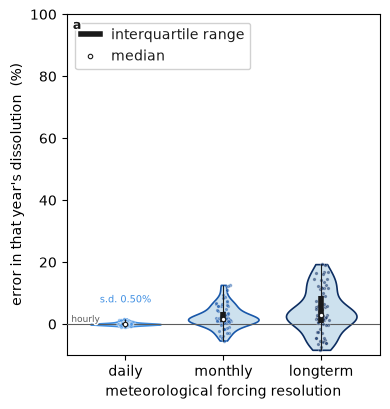

In [21]:
def draw_violins(ax):
    """One violin per case: KDE body, IQR bar, median tick, whiskers to the true range."""
    parts = ax.violinplot([ANNUAL[c] for c in SHOWN], positions=XPOS, widths=0.72,
                          showextrema=False, showmedians=False)
    for body, case in zip(parts["bodies"], SHOWN):
        body.set_edgecolor(CASE_COLOR[case])
        body.set_alpha(None)                      # violinplot presets alpha; set it on the colours
        body.set_facecolor((*body.get_facecolor()[0][:3], FILL_ALPHA))
        body.set_linewidth(1.2)
        body.set_zorder(2)

    for x, case in zip(XPOS, SHOWN):
        v = ANNUAL[case]
        if SHOW_POINTS:
            ax.plot(jitter(v.size, x), v, ls="none", marker="o", ms=2.6,
                    mfc=CASE_COLOR[case], mec="white", mew=0.35,
                    alpha=POINT_ALPHA, zorder=4)
        lo, q1, med, q3, hi = np.percentile(v, [0, 25, 50, 75, 100])
        ax.plot([x, x], [lo, hi], color=INK, lw=0.8, solid_capstyle="butt", zorder=5)
        ax.plot([x, x], [q1, q3], color=INK, lw=4.0, solid_capstyle="butt", zorder=6)
        ax.plot([x], [med], marker="o", ms=3.2, mfc="white", mec=INK, mew=0.8, zorder=7)

    reference_line(ax)
    category_axis(ax)
    legend_room(ax, rows=2)

    # The tightest case is a flat line on an axis scaled by the widest one. Its spread is the
    # result, so it gets a number rather than being left to the eye.
    tight = min(SHOWN, key=lambda c: ANNUAL[c].std(ddof=1))
    ax.annotate(f"s.d. {ANNUAL[tight].std(ddof=1):.2f}%",
                xy=(XPOS[SHOWN.index(tight)], 0.0), xytext=(0, 14),
                textcoords="offset points", ha="center", va="bottom",
                color=CASE_COLOR[tight], fontsize=7, path_effects=HALO, zorder=8)


with plt.rc_context(PUB_RC):
    fig_a, ax_a = plt.subplots(figsize=(PANEL_W, PANEL_H))

    draw_violins(ax_a)
    ax_a.set_ylabel("error in that year's dissolution  (%)")
    ax_a.set_ylim(-10, 100)
    # sample_note(ax_a)
    ax_a.legend(handles=[
        Line2D([], [], color=INK, lw=4.0, label="interquartile range"),
        Line2D([], [], ls="none", marker="o", ms=3.2, mfc="white", mec=INK, mew=0.8,
               label="median")],
        loc="upper left", handlelength=1.4, borderaxespad=0.6, labelcolor=INK, framealpha=0.9)
    panel_tag(ax_a, "a")
    reference_tag(ax_a, x=0.015, ha="left")

    if SHOW_TITLE:
        fig_a.suptitle("A single year's dissolution error widens as the forcing coarsens",
                       x=0.02, ha="left", color=INK)
    fig_a.tight_layout()
    save(fig_a, "fig3a")

plt.show()

## 4. Figure 3b — the error on the ten-year total

barplot

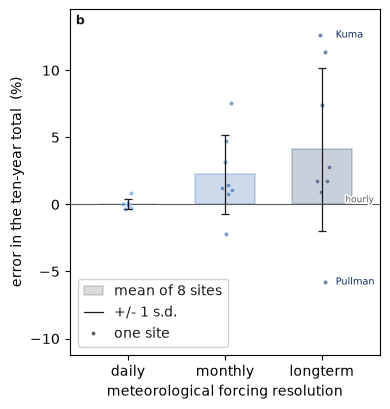

In [22]:
def label_site(ax, case, site, dx, dy, ha="left"):
    """Direct-label one site's point, for the few that carry the story."""
    x = XPOS[SHOWN.index(case)]
    ax.annotate(site, xy=(x, FINAL.loc[site, case]), xytext=(dx, dy),
                textcoords="offset points", ha=ha, va="center",
                color=CASE_COLOR[case], fontsize=7, path_effects=HALO, zorder=8)


with plt.rc_context(PUB_RC):
    fig_b, ax_b = plt.subplots(figsize=(PANEL_W, PANEL_H))

    TOTAL_MEAN, TOTAL_SD = draw_mean_sd_bars(ax_b, BY_SITE, ms=3.2)
    ax_b.set_ylabel("error in the ten-year total  (%)")

    WIDEST = SHOWN[-1]
    label_site(ax_b, WIDEST, FINAL[WIDEST].idxmin(), 10, 0)
    label_site(ax_b, WIDEST, FINAL[WIDEST].idxmax(), 10, 0)

    mean_sd_legend(ax_b, f"mean of {len(SITES)} sites", "one site", ms=3.2)
    panel_tag(ax_b, "b")
    reference_tag(ax_b)

    if SHOW_TITLE:
        fig_b.suptitle("Coarser forcing over-dissolves the feedstock over ten years",
                       x=0.02, ha="left", color=INK)
    fig_b.tight_layout()
    save(fig_b, "fig3b")

plt.show()

## 5. Figure 3c — the year-to-year error as a mean and a standard deviation

Note whiskers is standard deviation of the sample (not standard error or uncertainty). 

daily      +0.12 +/-  0.50 %   (n = 77)
monthly    +2.37 +/-  3.61 %   (n = 77)
longterm   +4.16 +/-  6.88 %   (n = 77)


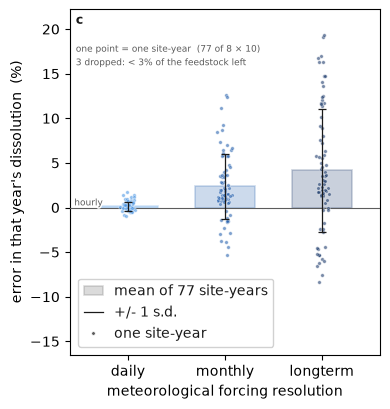

In [23]:
with plt.rc_context(PUB_RC):
    fig_c, ax_c = plt.subplots(figsize=(PANEL_W, PANEL_H))

    YEAR_MEAN, YEAR_SD = draw_mean_sd_bars(ax_c, ANNUAL, ms=2.6)
    ax_c.set_ylabel("error in that year's dissolution  (%)")
    sample_note(ax_c)

    mean_sd_legend(ax_c, f"mean of {N_KEPT} site-years", "one site-year", ms=2.6)
    panel_tag(ax_c, "c")
    reference_tag(ax_c, x=0.015, ha="left")

    if SHOW_TITLE:
        fig_c.suptitle("Mean and spread of a single year's dissolution error",
                       x=0.02, ha="left", color=INK)
    fig_c.tight_layout()
    save(fig_c, "fig3c")

for case in SHOWN:
    print(f"{case:9s} {YEAR_MEAN[case]:+6.2f} +/- {YEAR_SD[case]:5.2f} %   (n = {N_KEPT})")
plt.show()

## 6. Caption numbers

In [25]:
per_year = pd.DataFrame(
    {case: {"mean": ANNUAL[case].mean(),
            "median": np.median(ANNUAL[case]),
            "s.d.": ANNUAL[case].std(ddof=1),
            "min": ANNUAL[case].min(),
            "max": ANNUAL[case].max(),
            "% of site-years below zero": 100 * (ANNUAL[case] < 0).mean()}
     for case in SHOWN})

print(f"figures 3a and 3c -- error in a single year's dissolution, {N_KEPT} site-years with "
      f"≥ {FEEDSTOCK_MIN_PCT:g}% of the feedstock left, relative to {REFERENCE}\n")
display(per_year.round(2))

ten_year = pd.DataFrame({"mean": TOTAL_MEAN, f"s.d. ({len(SITES)} sites)": TOTAL_SD,
                         "min": FINAL[SHOWN].min(), "min site": FINAL[SHOWN].idxmin(),
                         "max": FINAL[SHOWN].max(), "max site": FINAL[SHOWN].idxmax()})

print(f"\nfigure 3b -- error in the ten-year total, all {len(SITES)} sites, "
      f"relative to {REFERENCE}\n")
display(ten_year.round(2))

figures 3a and 3c -- error in a single year's dissolution, 77 site-years with ≥ 3% of the feedstock left, relative to hourly



,daily,monthly,longterm
mean,0.12,2.37,4.16
median,0.02,1.54,2.98
s.d.,0.50,3.61,6.88
min,-0.93,-5.31,-8.31
max,1.75,12.64,19.35
% of site-years below zero,45.45,18.18,24.68



figure 3b -- error in the ten-year total, all 8 sites, relative to hourly



,mean,s.d. (8 sites),min,min site,max,max site
daily,0.05,0.35,-0.31,Palouse,0.83,HoustonBlack
monthly,2.23,2.93,-2.22,Pullman,7.53,HoustonBlack
longterm,4.10,6.06,-5.76,Pullman,12.64,Kuma


In [13]:
# ---